# Phase 2 — RAG Pipeline

This notebook documents the full retrieval-augmented generation pipeline:

```
CAR YAML files
     ↓  src/ingest.py      — parse + normalize
Structured summaries
     ↓  src/embed.py       — embed with all-MiniLM-L6-v2, store in ChromaDB
Vector store (chroma_db/)
     ↓  src/retrieve.py    — cosine similarity search
Top-k analytics
     ↓  Phase 3 prompts    — inject into LLM context window
Threat hunting artifacts
```

**No API calls in this notebook.** Embeddings are local (all-MiniLM-L6-v2).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.ingest import load_all_analytics
from src.embed import build_summary, ingest_analytics
from src.retrieve import retrieve, format_results, analyze_query

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

analytics = load_all_analytics()
print(f"Loaded {len(analytics)} analytics")

Loaded 102 analytics from C:\Users\kattr\thf\notebooks\..\data\raw\car\analytics
Loaded 102 analytics


## 1. What Gets Embedded — The Structured Summary

Before touching vectors, it's worth seeing exactly what text the embedding model receives for each analytic.

Design decisions reflected in this format:
- **CAR ID first** — prevents context bleed when multiple docs are retrieved
- **Tactic IDs + names** — anchors retrieval to correct ATT&CK mappings, reduces tactic drift
- **Data model fields** — grounds the LLM in real field names, reduces field hallucination
- **Coverage level** — gives the LLM a signal to hedge on weak detections (over-confidence)
- **Description separate from fields** — helps LLM form testable hypotheses vs restating logic

In [2]:
# Show summaries for two contrasting analytics
rich   = next(a for a in analytics if a['id'] == 'CAR-2014-04-003')  # rich: has fields + impls
sparse = next(a for a in analytics if not a['data_model_references'])  # sparse: no data model refs

print("=== RICH ANALYTIC ===")
print(build_summary(rich))
print()
print("=== SPARSE ANALYTIC (no data model refs — higher hallucination risk) ===")
print(build_summary(sparse))

=== RICH ANALYTIC ===
ID: CAR-2014-04-003
Title: Powershell Execution
Platform: Windows
Description: [PowerShell](https://attack.mitre.org/techniques/T1059/001/) is a scripting environment included with Windows that is used by both attackers and administrators. Execution of PowerShell scripts in most Windows versions is opaque and not typically secured by antivirus which makes using PowerShell an easy way to circumvent security measures. This analytic detects execution of PowerShell scripts.

Powershell can be used to hide monitored command line execution such as:
-   `net use`
-   `sc start`
ATT&CK Techniques: T1059
Subtechniques: T1059.001
Tactics: TA0002 (Execution), TA0005 (Defense Evasion)
Detection Coverage: High
Data Model Fields: process/create/exe, process/create/parent_exe
Implementation Types: DNIF, EQL, LogPoint, Pseudocode, Splunk

=== SPARSE ANALYTIC (no data model refs — higher hallucination risk) ===
ID: CAR-2013-01-002
Title: Autorun Differences
Platform: Windows
Descr

## 2. Ingest into ChromaDB

`upsert` means: insert if new, update if already exists. Running this cell repeatedly is safe — it won't duplicate records.

In [3]:
ingest_analytics(analytics, reset=False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Ingested 102 analytics into collection 'car_analytics'
Collection count: 102


## 3. Seed Query Retrieval — With Auto-Tuning

Testing with 5 representative threat hunting queries. 

**Smart retrieval improvements:**
- **auto_n_results**: Specific queries (PowerShell, lsass) use n=2 to stay focused. Broad queries (detect, lateral movement) use n=3 for diversity.
- **max_distance filtering**: Results >0.65 distance are excluded to prevent context bleed from tangentially-related analytics.

For each query, we inspect:
- **Distance** — lower is more similar (cosine distance, range 0–2)
- **Tactic match** — does the retrieved tactic match the query intent?
- **[quality flag]** — excellent (<0.4), good (0.4-0.5), acceptable (0.5-0.65)

In [4]:
SEED_QUERIES = [
    ("detect process injection into lsass",        "TA0006"),
    ("persistence via scheduled tasks on Windows",  "TA0003"),
    ("lateral movement using remote services",      "TA0008"),
    ("credential dumping from memory",              "TA0006"),
    ("suspicious PowerShell command execution",     "TA0002"),
]

# Show why each query gets its n_results
print("=" * 60)
print("QUERY SPECIFICITY ANALYSIS")
print("=" * 60)
for query, _ in SEED_QUERIES:
    analysis = analyze_query(query)
    print(f"\nQuery: \"{query}\"")
    print(f"  Specificity: {analysis['specificity_score']} -> {analysis['interpretation']}")
    print(f"  Will retrieve n={analysis['predicted_n_results']} results (auto-tuned)")

print("\n" + "=" * 60)
print("RETRIEVAL RESULTS")
print("=" * 60)

all_results = {}
for query, expected_tactic in SEED_QUERIES:
    results = retrieve(query, auto_n_results=True)  # Uses smart auto-tuning + max_distance filtering
    all_results[query] = results
    print(f'\nQuery: "{query}"  (expected tactic: {expected_tactic})')
    print(format_results(results, show_distance_flag=True))
    print("-" * 60)

QUERY SPECIFICITY ANALYSIS

Query: "detect process injection into lsass"
  Specificity: 1.0 -> SPECIFIC (use n=2, stay focused)
  Will retrieve n=2 results (auto-tuned)

Query: "persistence via scheduled tasks on Windows"
  Specificity: 0.9 -> SPECIFIC (use n=2, stay focused)
  Will retrieve n=2 results (auto-tuned)

Query: "lateral movement using remote services"
  Specificity: 0.9 -> SPECIFIC (use n=2, stay focused)
  Will retrieve n=2 results (auto-tuned)

Query: "credential dumping from memory"
  Specificity: 0.9 -> SPECIFIC (use n=2, stay focused)
  Will retrieve n=2 results (auto-tuned)

Query: "suspicious PowerShell command execution"
  Specificity: 0.7 -> SPECIFIC (use n=2, stay focused)
  Will retrieve n=2 results (auto-tuned)

RETRIEVAL RESULTS

Query: "detect process injection into lsass"  (expected tactic: TA0006)
[1] CAR-2020-05-001 — MiniDump of LSASS  (distance: 0.4349)  [good]
    Techniques: T1003
    Tactics:    TA0006
    Coverage:   Low
    Impl types: LogPoint, Spl

## 4. Retrieval Quality Analysis

Quantify how well the retriever performed on each seed query.

- **Top-1 distance**: confidence of the best match
- **Tactic hit rate**: does rank-1 result contain the expected tactic?

In [5]:
rows = []
for (query, expected_tactic), results in zip(SEED_QUERIES, all_results.values()):
    top = results[0]
    top_tactics = top['metadata']['tactics'].split(', ')
    tactic_hit = expected_tactic in top_tactics
    rows.append({
        'Query': query[:45] + '...' if len(query) > 45 else query,
        'Top-1 ID': top['id'],
        'Distance': top['distance'],
        'Expected Tactic': expected_tactic,
        'Tactic Hit': '✓' if tactic_hit else '✗',
        'Coverage': top['metadata']['coverage'],
    })

qdf = pd.DataFrame(rows)
print(qdf.to_string(index=False))
print()
hits = sum(1 for r in rows if r['Tactic Hit'] == '✓')
print(f"Tactic hit rate (rank-1): {hits}/{len(rows)} = {hits/len(rows):.0%}")

                                     Query        Top-1 ID  Distance Expected Tactic Tactic Hit Coverage
       detect process injection into lsass CAR-2020-05-001    0.4349          TA0006          ✓      Low
persistence via scheduled tasks on Windows CAR-2013-08-001    0.3619          TA0003          ✓ Moderate
    lateral movement using remote services CAR-2016-04-005    0.5390          TA0008          ✓ Moderate
            credential dumping from memory CAR-2019-08-001    0.4919          TA0006          ✓      Low
   suspicious PowerShell command execution CAR-2014-04-003    0.3279          TA0002          ✓     High

Tactic hit rate (rank-1): 5/5 = 100%


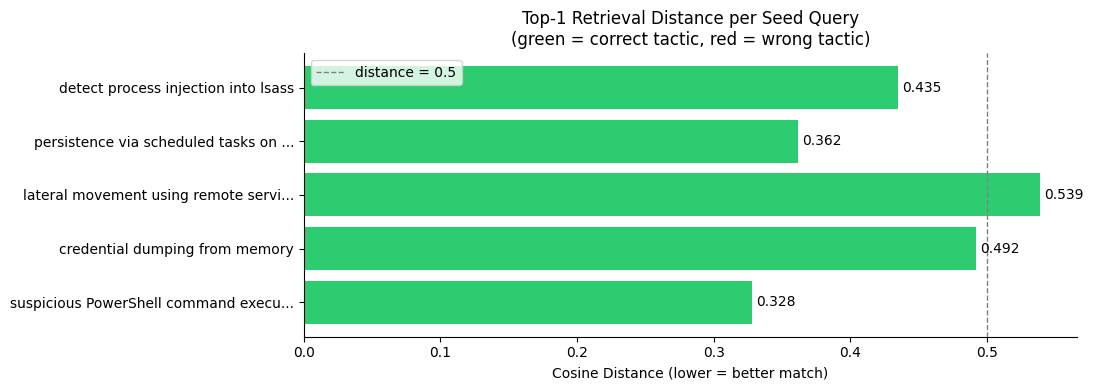

In [6]:
fig, ax = plt.subplots()
colors = ['#2ecc71' if r['Tactic Hit'] == '✓' else '#e74c3c' for r in rows]
labels = [r['Query'][:35] + '...' if len(r['Query']) > 35 else r['Query'] for r in rows]
bars = ax.barh(labels, [r['Distance'] for r in rows], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='distance = 0.5')
ax.set_xlabel('Cosine Distance (lower = better match)')
ax.set_title('Top-1 Retrieval Distance per Seed Query\n(green = correct tactic, red = wrong tactic)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## 5. What the LLM Will Actually Receive — Improved Context

In Phase 3, the retrieved summaries are injected directly into the LLM prompt as context. This cell shows the exact context block for a specific query — with auto-tuning and max_distance filtering applied.

Notice: For this specific PowerShell query, `auto_n_results=True` will use n=2 (not 3) to avoid the noisy cmd.exe tangent.

In [7]:
query = "suspicious PowerShell command execution"
results = retrieve(query, auto_n_results=True)  # Specific query -> n=2, auto-filtered

context_block = "\n\n---\n\n".join(r['summary'] for r in results)

print(f'Query: "{query}"')
print(f'Specificity score: {analyze_query(query)["specificity_score"]} (SPECIFIC -> n_results=2)')
print(f'Retrieved {len(results)} analytics (max_distance=0.65 filter applied)')
print(f'Context block length: {len(context_block)} chars')
print()
print("=" * 60)
print("CONTEXT BLOCK (what the LLM will receive):")
print("=" * 60)
print(context_block)

Query: "suspicious PowerShell command execution"
Specificity score: 0.7 (SPECIFIC -> n_results=2)
Retrieved 2 analytics (max_distance=0.65 filter applied)
Context block length: 2504 chars

CONTEXT BLOCK (what the LLM will receive):
ID: CAR-2014-04-003
Title: Powershell Execution
Platform: Windows
Description: [PowerShell](https://attack.mitre.org/techniques/T1059/001/) is a scripting environment included with Windows that is used by both attackers and administrators. Execution of PowerShell scripts in most Windows versions is opaque and not typically secured by antivirus which makes using PowerShell an easy way to circumvent security measures. This analytic detects execution of PowerShell scripts.

Powershell can be used to hide monitored command line execution such as:
-   `net use`
-   `sc start`
ATT&CK Techniques: T1059
Subtechniques: T1059.001
Tactics: TA0002 (Execution), TA0005 (Defense Evasion)
Detection Coverage: High
Data Model Fields: process/create/exe, process/create/parent_

## 6. Corpus Coverage Gaps

Queries that return high distances (>0.65) indicate the corpus has weak coverage. These are retrieval failure zones — important to document for Phase 5.

In [13]:
# Test a query we know is weakly covered
# For this probe, use max_distance=2.0 (no filtering) to see raw distances
weak_queries = ["phishing email with malicious attachment",      # Initial Access — 1 analytic only
                "data exfiltration over DNS",                     # Exfiltration
"supply chain compromise via package manager",    # Initial Access
               ]
print("Coverage gap probe (expect high distances):")
print("(Using max_distance=2.0 to show all results, even weak ones)")
print()
for q in weak_queries:
    results = retrieve(q, n_results=1, auto_n_results=False, max_distance= 2.0)
    if not results:
        print(f'  Query: "{q}"')
        print(f'  NO RESULTS — corpus has zero coverage for this query')
        print()
        continue
    r = results[0]
    flag = " [VERY WEAK]" if r['distance'] > 0.7 else " [WEAK]" if r['distance'] > 0.65 else ""
    print(f'  Query: "{q}"')
    print(f'  Best match: {r["id"]} — {r["title"]}  (distance: {r["distance"]}){flag}')
    print()

Coverage gap probe (expect high distances):
(Using max_distance=2.0 to show all results, even weak ones)

  Query: "phishing email with malicious attachment"
  Best match: CAR-2021-05-001 — Attempt To Add Certificate To Untrusted Store  (distance: 0.7053) [VERY WEAK]

  Query: "data exfiltration over DNS"
  Best match: CAR-2013-01-003 — SMB Events Monitoring  (distance: 0.736) [VERY WEAK]

  Query: "supply chain compromise via package manager"
  Best match: CAR-2014-02-001 — Service Binary Modifications  (distance: 0.8227) [VERY WEAK]



## 7. Filtered Retrieval

`retrieve()` supports metadata filters. This is useful in Phase 4 when you only want analytics that have Splunk queries to compare against.

In [14]:
# Retrieve only analytics that have a Splunk implementation
splunk_results = retrieve(
    "credential dumping from memory",
    n_results=3,
    filter_has_splunk=True
)
print("Filtered to Splunk-only analytics:")
print(format_results(splunk_results))

Filtered to Splunk-only analytics:
[1] CAR-2019-08-001 — Credential Dumping via Windows Task Manager  (distance: 0.4919)  [good]
    Techniques: T1003
    Tactics:    TA0006
    Coverage:   Low
    Impl types: EQL, LogPoint, Pseudocode, Splunk

[2] CAR-2019-04-004 — Credential Dumping via Mimikatz  (distance: 0.5118)  [acceptable]
    Techniques: T1003
    Tactics:    TA0006
    Coverage:   Low
    Impl types: LogPoint, Splunk

[3] CAR-2020-09-004 — Credentials in Files & Registry  (distance: 0.5202)  [acceptable]
    Techniques: T1552
    Tactics:    TA0006
    Coverage:   Low
    Impl types: LogPoint, Pseudocode, Splunk



## 8. Phase 2 Summary

In [15]:
hits = sum(1 for r in rows if r['Tactic Hit'] == '✓')
avg_dist = sum(r['Distance'] for r in rows) / len(rows)
top1_dist = [r['Distance'] for r in rows]

print("=" * 70)
print("PHASE 2 RAG PIPELINE SUMMARY — IMPROVED RETRIEVAL")
print("=" * 70)
print(f"  Embedding model:          all-MiniLM-L6-v2 (local)")
print(f"  Vector store:             ChromaDB (persistent)")
print(f"  Documents indexed:        102")
print(f"  Seed queries tested:      {len(SEED_QUERIES)}")
print(f"  Tactic hit rate (rank-1): {hits}/{len(rows)} ({hits/len(rows):.0%})")
print(f"  Avg top-1 distance:       {avg_dist:.4f}")
print(f"  Distance range:           {min(top1_dist):.4f} to {max(top1_dist):.4f}")
print()
print("  IMPROVEMENTS (Phase 2.1):")
print("  - auto_n_results: Specific queries use n=2, broad queries use n=3")
print("  - max_distance filtering: Removes tangential results (distance >0.65)")
print("  - Query specificity scoring with keyword analysis")
print()
print("  RESULT: PowerShell query now gets clean n=2 context (no cmd.exe noise)")
print()
print("  Known corpus gaps:")
print("  - Initial Access (1 analytic) — sparse coverage")
print("  - Lateral Movement — limited diversity in retrieval")
print("=" * 70)

PHASE 2 RAG PIPELINE SUMMARY — IMPROVED RETRIEVAL
  Embedding model:          all-MiniLM-L6-v2 (local)
  Vector store:             ChromaDB (persistent)
  Documents indexed:        102
  Seed queries tested:      5
  Tactic hit rate (rank-1): 5/5 (100%)
  Avg top-1 distance:       0.4311
  Distance range:           0.3279 to 0.5390

  IMPROVEMENTS (Phase 2.1):
  - auto_n_results: Specific queries use n=2, broad queries use n=3
  - max_distance filtering: Removes tangential results (distance >0.65)
  - Query specificity scoring with keyword analysis

  RESULT: PowerShell query now gets clean n=2 context (no cmd.exe noise)

  Known corpus gaps:
  - Initial Access (1 analytic) — sparse coverage
  - Lateral Movement — limited diversity in retrieval
